# Exploratory Data Analysis

This notebook contains exploratory analysis and early experiments for the patient disease classification problem.

The final training and evaluation pipeline is implemented in:

`src/ml_patient_classifier/`

In [24]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
# Load the dataset
df = pd.read_csv('../data/raw/heart.csv')
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [26]:
# Basic info about the dataset
df.info(), df.isna().sum(), df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


(None,
 Age               0
 Sex               0
 ChestPainType     0
 RestingBP         0
 Cholesterol       0
 FastingBS         0
 RestingECG        0
 MaxHR             0
 ExerciseAngina    0
 Oldpeak           0
 ST_Slope          0
 HeartDisease      0
 dtype: int64,
 np.int64(0))

In [27]:
# Unique values in categorical columns
df['Sex'].unique(), df['ChestPainType'].unique(), df['RestingECG'].unique(), df['ExerciseAngina'].unique(), df['ST_Slope'].unique()

(array(['M', 'F'], dtype=object),
 array(['ATA', 'NAP', 'ASY', 'TA'], dtype=object),
 array(['Normal', 'ST', 'LVH'], dtype=object),
 array(['N', 'Y'], dtype=object),
 array(['Up', 'Flat', 'Down'], dtype=object))

- ChestPainType: ATA (atypical angina), NAP (non-anginal pain), ASY (asymptomatic), TA (typical angina) - type of chest pain

- RestingBP (Resting blood pressure), Cholesterol, FastingBS (Fasting blood sugar, > 120 mg/dl, 1 = true, 0 = false) - people with metabolic diseases, e.g., hypertension, elevated cholesterol levels, diabetes, or obesity, have an increased risk of cardiovascular diseases such as heart attacks
- Resting ECG (Resting electrocardiographic results): Normal, ST (having ST-T wave abnormality), LVH (probable or definite left ventricular hypertrophy) - ECG test result
- MaxHR (Maximum heart rate) - maximum heart rate
- ExerciseAngina - a variable determining whether the patient experiences pain induced by exercise
- Oldpeak - ST segment depression (between the end of depolarization and the beginning of ventricular repolarization) on ECG, induced by exercise
- ST_Slope: Up, Flat, Down - elevation, no change, or depression of the ST segment - the most characteristic is myocardial infarction with ST elevation, but non-STEMI (non-STEMI) myocardial infarction without such elevation may also occur; ST segment depression is a feature of cardiac ischemia

In [28]:
# Statistical summary of the dataset
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


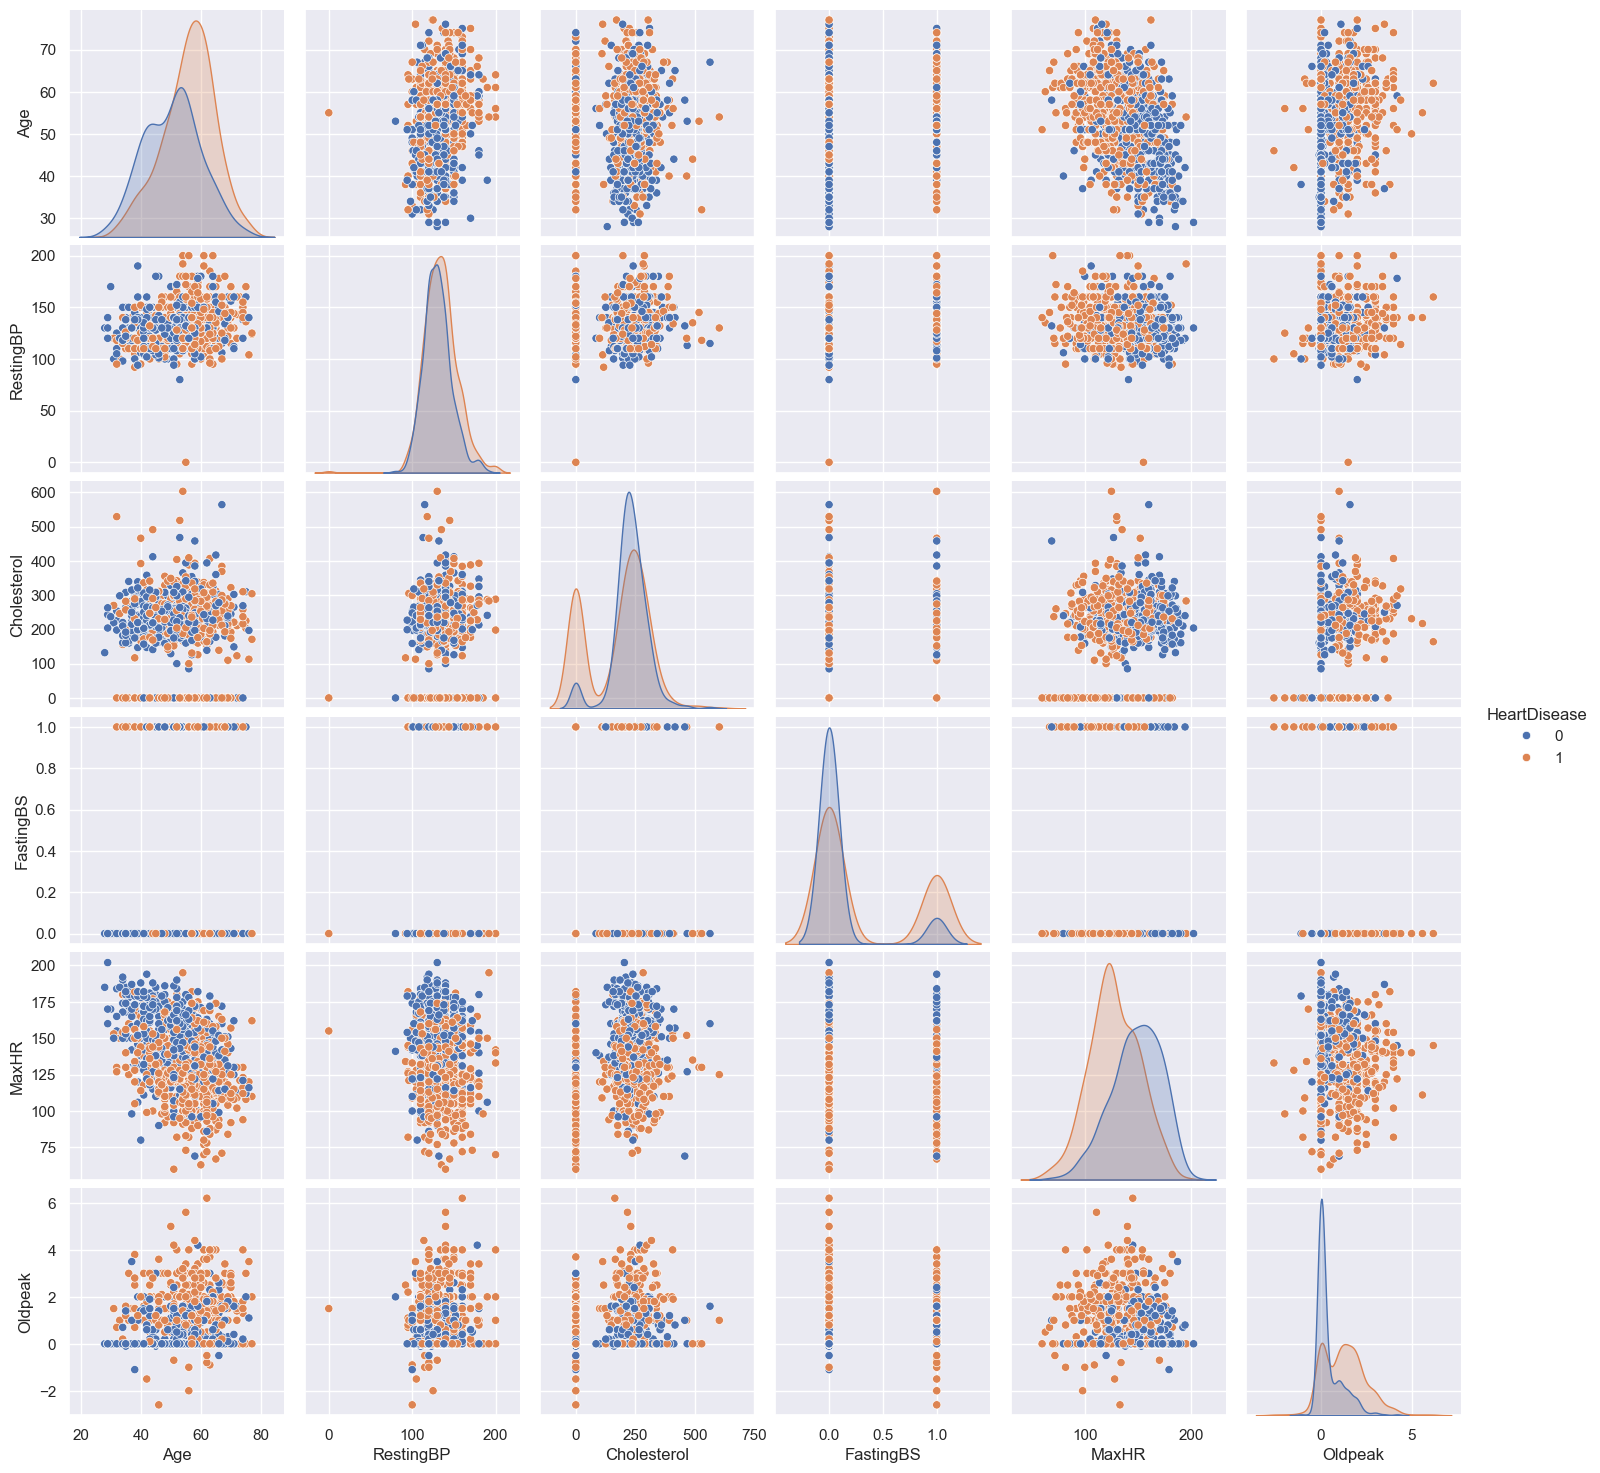

In [29]:
# Pairplots with hue based on the target variable 'HeartDisease'
sns.pairplot(data=df, hue='HeartDisease');

In [30]:
# Value counts of the target
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

- The number of disease cases increases with age - potentially possible conversion of the variable from numeric to ordinal

- Elevated blood sugar levels are more common in sick people than in healthy people,
- Sick people have a lower maximum heart rate
- There are many observations with zero cholesterol levels and some observations with zero blood pressure levels - the data requires handling missing values
- Healthy people usually have an Oldpeak value around 0, and the variable value is generally higher for sick people

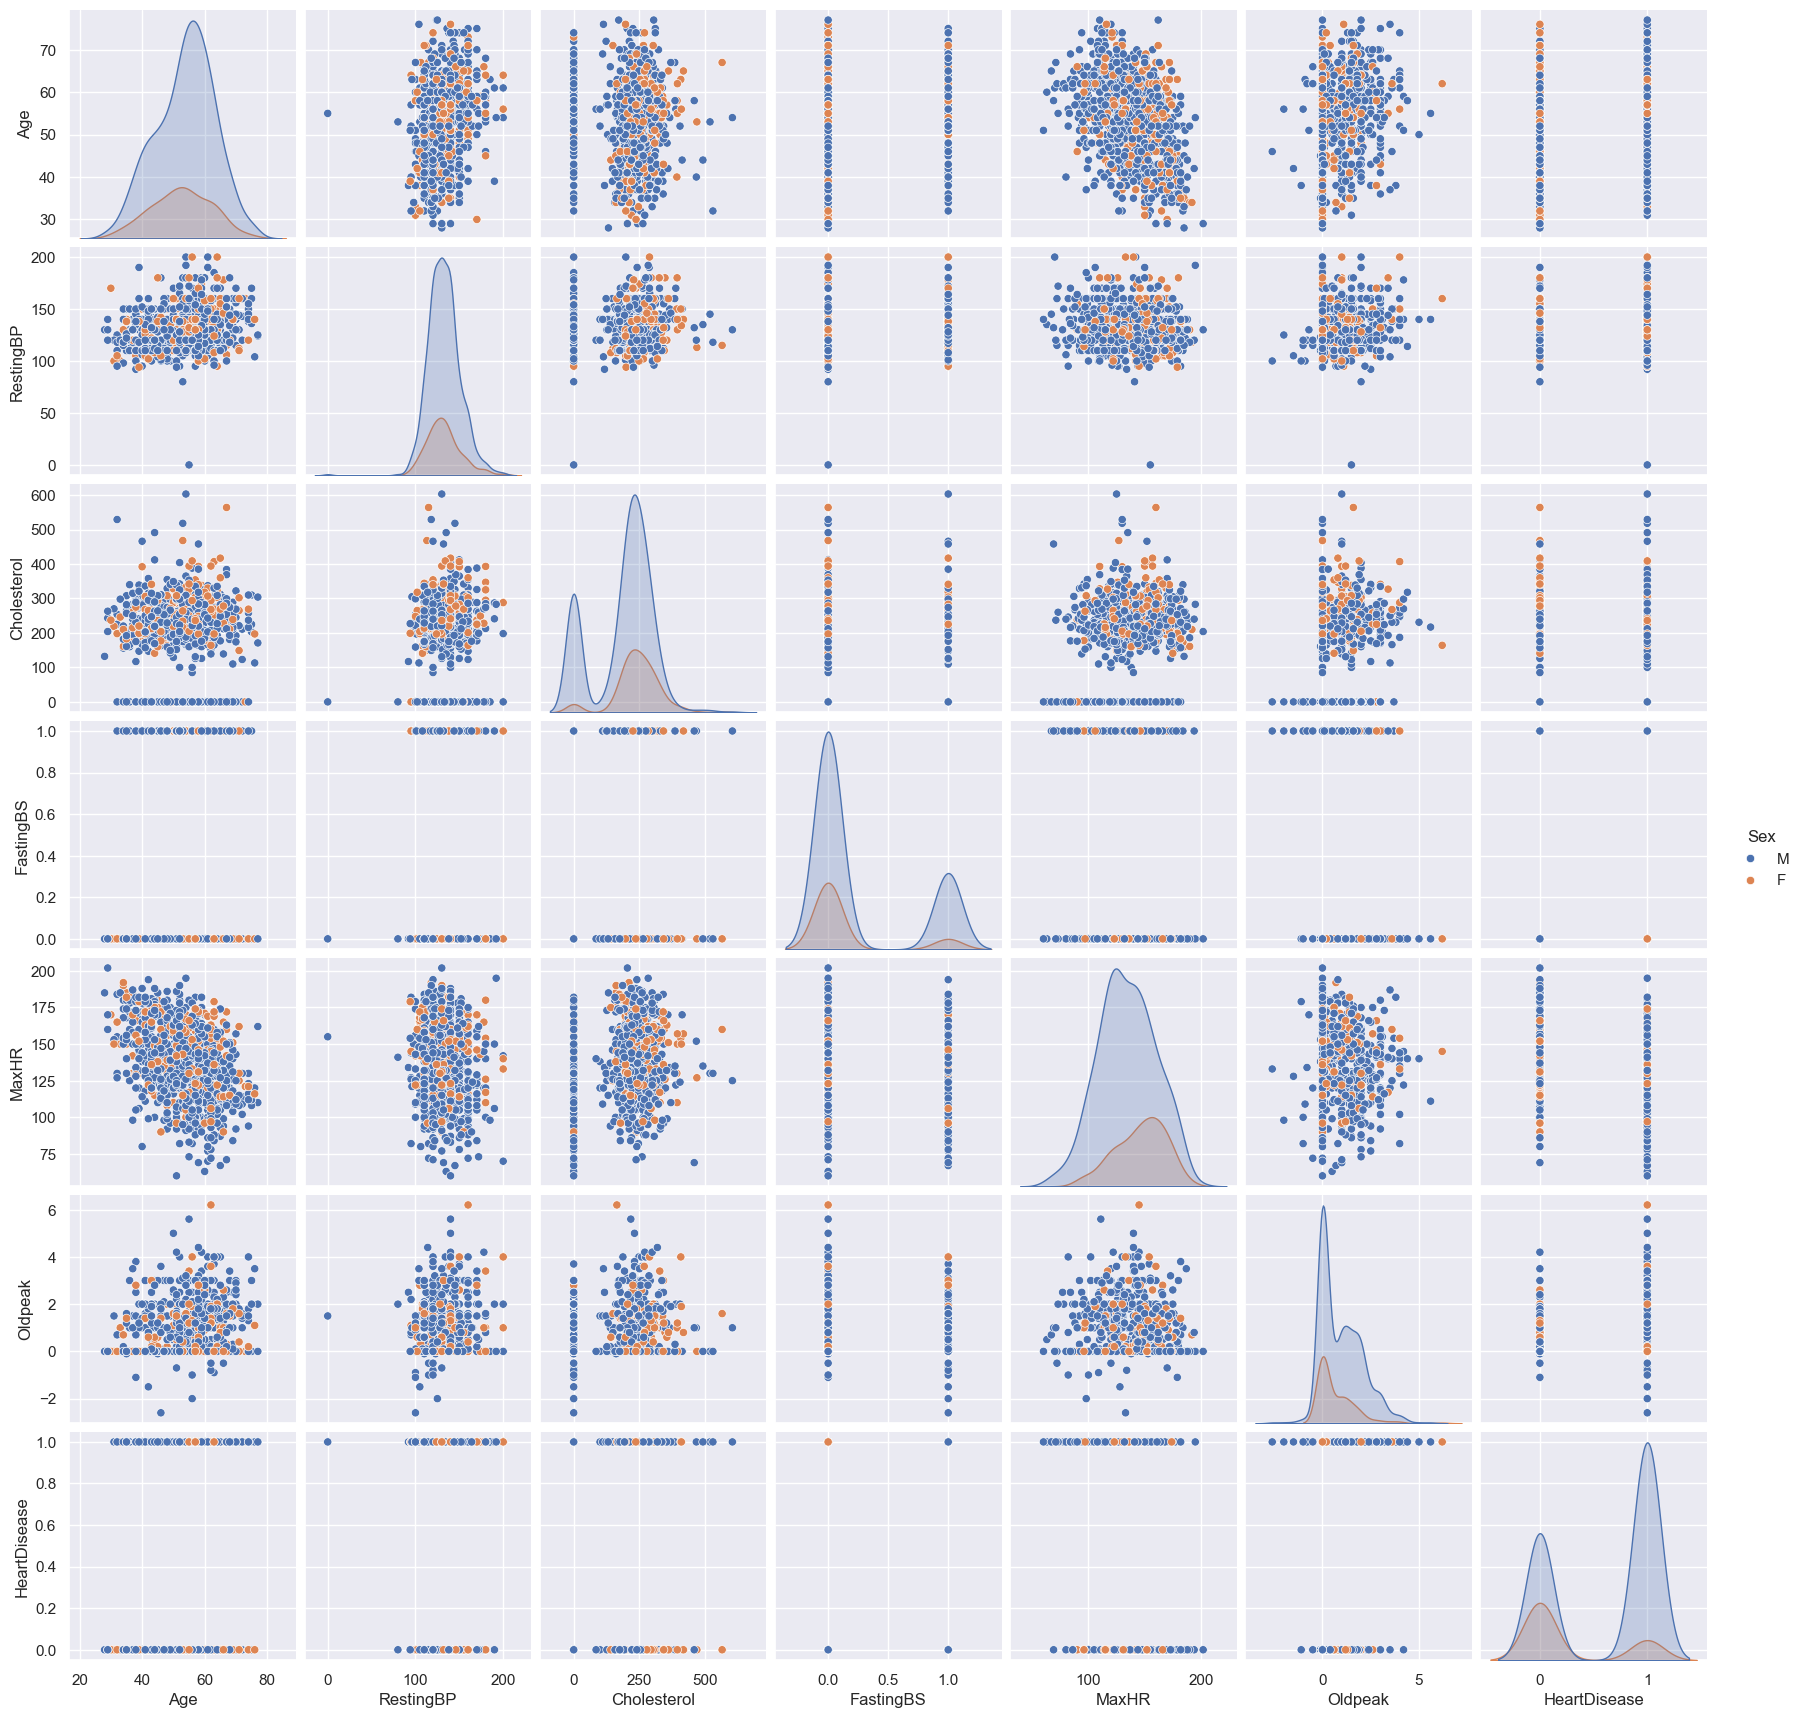

In [31]:
# Pairplots with hue based on gender
sns.pairplot(data=df, hue='Sex');

In [32]:
# Number of men and women in the dataset
df['Sex'].value_counts()

Sex
M    725
F    193
Name: count, dtype: int64

- Men predominate in the dataset (over 3 times more cases)

- Most women do not have elevated blood sugar levels
- Most women and men have similar blood pressure and cholesterol levels (similar distributions)
- Men are more likely to get develop a condition than women

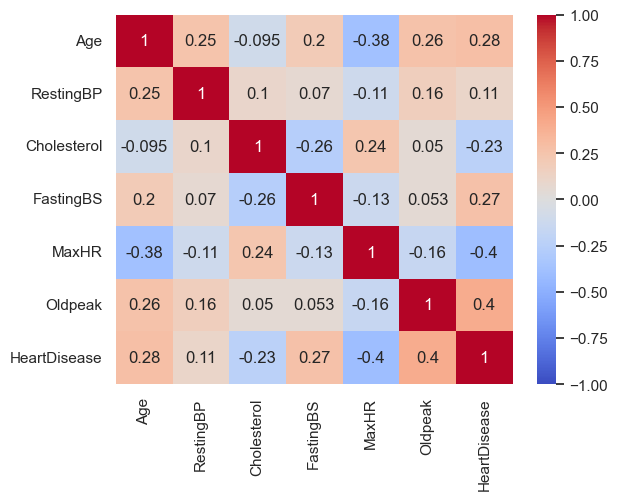

In [33]:
# Correlation heatmap for numerical features
sns.heatmap(df.select_dtypes(include=np.number).corr(), vmin=-1, vmax=1, cmap='coolwarm', annot=True);

- No variables show a strong correlation

- A moderate correlation exists between the target variable and maximum heart rate (negative) and oldpeak (positive), as well as between maximum heart rate and age (negative)
- The remaining correlations are weak or very weak
- Blood pressure level shows the lowest correlation with the target variable

In [34]:
# Skewness and kurtosis for numerical features
df.select_dtypes(include=np.number).skew(), df.select_dtypes(include=np.number).kurtosis()

(Age            -0.195933
 RestingBP       0.179839
 Cholesterol    -0.610086
 FastingBS       1.264484
 MaxHR          -0.144359
 Oldpeak         1.022872
 HeartDisease   -0.215086
 dtype: float64,
 Age            -0.386140
 RestingBP       3.271251
 Cholesterol     0.118208
 FastingBS      -0.401960
 MaxHR          -0.448248
 Oldpeak         1.203064
 HeartDisease   -1.958008
 dtype: float64)

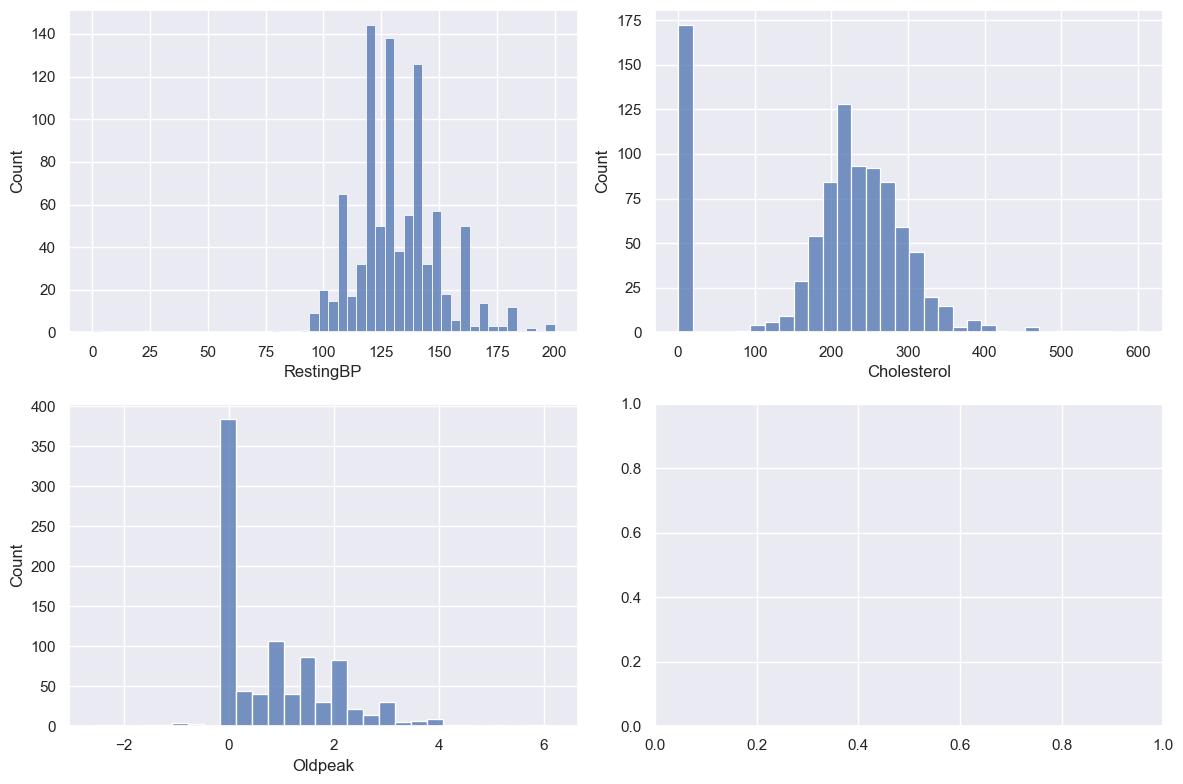

In [35]:
# Histograms for numerical features with high skewness
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df['RestingBP'], ax=axes[0, 0])
sns.histplot(df['Cholesterol'], ax=axes[0, 1])
sns.histplot(df['Oldpeak'], ax=axes[1, 0])
plt.tight_layout()
plt.show()

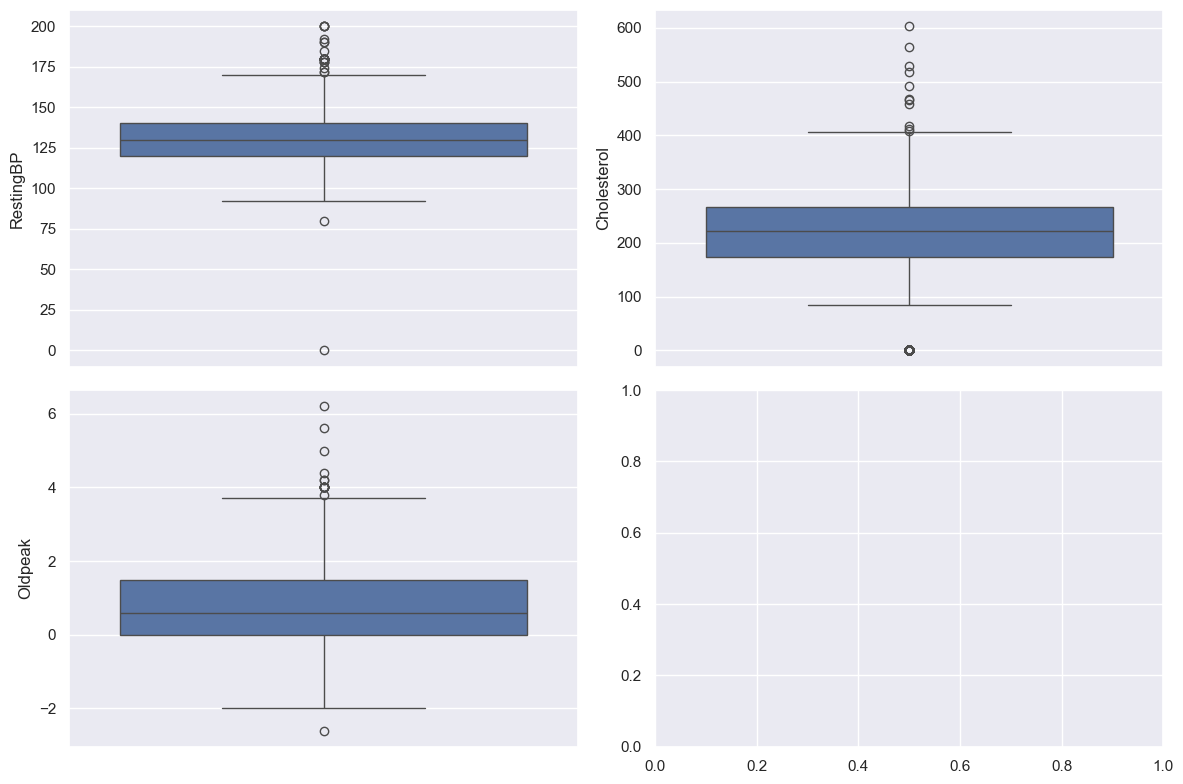

In [36]:
# Boxplots for numerical features with high skewness
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.boxplot(df['RestingBP'], ax=axes[0, 0])
sns.boxplot(df['Cholesterol'], ax=axes[0, 1])
sns.boxplot(df['Oldpeak'], ax=axes[1, 0])
plt.tight_layout()
plt.show()